In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/LENOVO/layoffs-data-analysis/data/cleaned/layoffs_cleaned.csv', parse_dates=['date', 'date_added'])
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Patreon,SF Bay Area,93.0,2026-07-23,0.2,Media,https://techcrunch.com/2026/07/23/patreon-lays...,Series F,413.0,United States,2026-07-24
1,Amazon,Port St. Lucie,1110.0,2026-07-22,NaN,Retail,https://www.msn.com/en-us/money/companies/amaz...,Post-IPO,8100.0,United States,2026-07-24
2,Monday.com,"Tel Aviv, Non-U.S.",630.0,2026-07-22,0.2,Product,https://techcrunch.com/2026/07/22/monday-com-l...,Post-IPO,384.0,Israel,2026-07-23
3,Amazon,Seattle,NaN,2026-07-22,NaN,Retail,https://www.reuters.com/business/world-at-work...,Post-IPO,8100.0,United States,2026-07-24
4,Uber,SF Bay Area,NaN,2026-07-22,NaN,Transportation,https://www.bloomberg.com/news/articles/2026-0...,Post-IPO,25200.0,United States,2026-07-24


In [ ]:
#1: Top industries by layoffs

top_industries = df[df['industry'] != 'Other'].groupby('industry')['total_laid_off'].sum().sort_values(ascending=False).head(10)
top_industries 

industry
Retail            107873.0
Hardware          105100.0
Consumer           98144.0
Finance            70012.0
Transportation     67402.0
Food               52101.0
Healthcare         40298.0
Infrastructure     24835.0
Travel             24340.0
Sales              22048.0
Name: total_laid_off, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11824\2365466635.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')


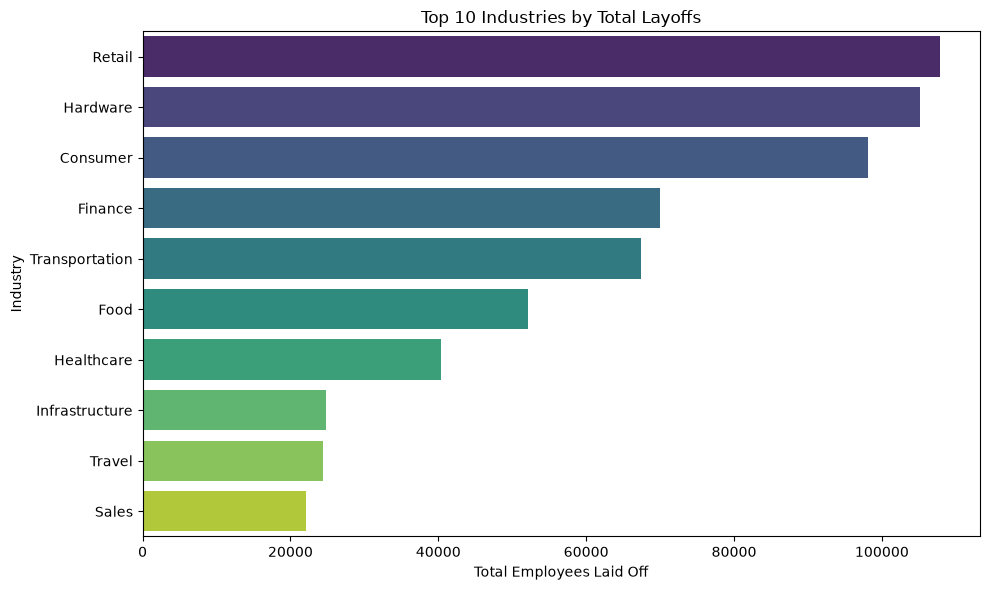

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')
plt.xlabel('Total Employees Laid Off')
plt.ylabel('Industry')
plt.title('Top 10 Industries by Total Layoffs')
plt.tight_layout()
plt.savefig('../visuals/top_industries.png', dpi=150)
plt.show()

In [ ]:
#2: Monthly trend over time

monthly_layoffs = df.groupby(df['date'].dt.to_period('M'))['total_laid_off'].sum()
monthly_layoffs.index = monthly_layoffs.index.strftime('%Y %b')
monthly_layoffs

date
2020 Mar     9628.0
2020 Apr    26710.0
2020 May    25804.0
2020 Jun     7627.0
2020 Jul     7112.0
             ...   
2026 Mar    16663.0
2026 Apr     5085.0
2026 May    29002.0
2026 Jun    26460.0
2026 Jul    10384.0
Name: total_laid_off, Length: 77, dtype: float64

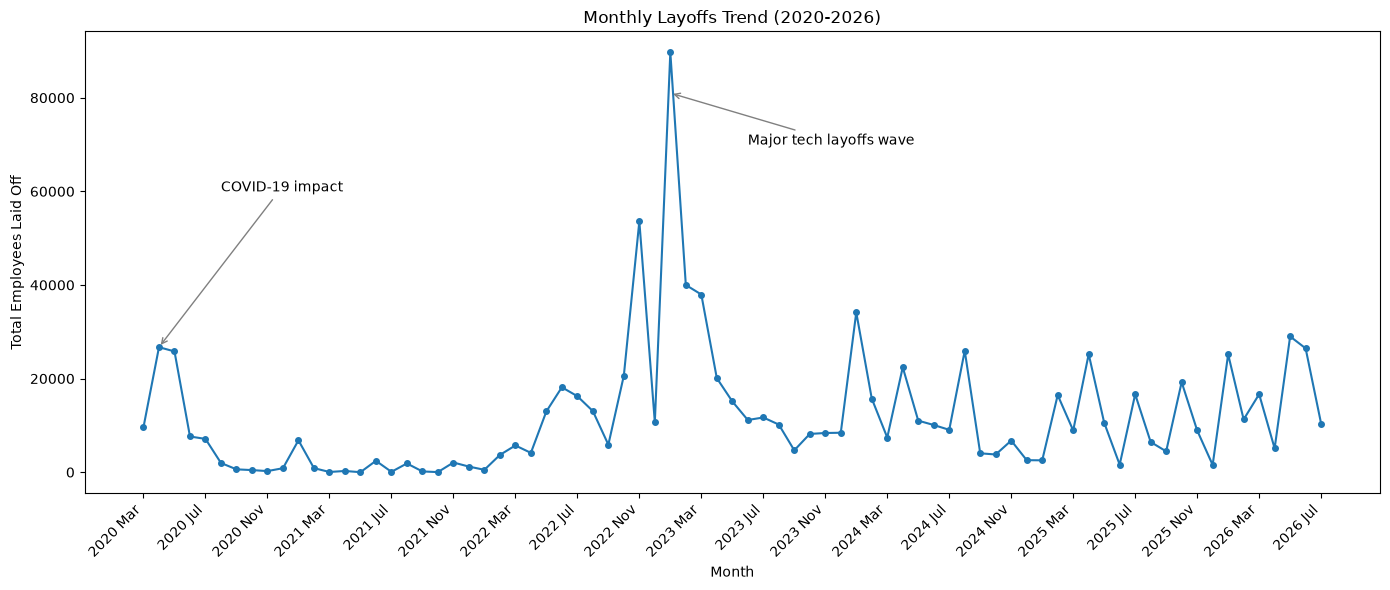

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_layoffs.index, monthly_layoffs.values, marker='o', linewidth=1.5, markersize=4)

tick_positions = range(0, len(monthly_layoffs), 4)
plt.xticks(tick_positions, [monthly_layoffs.index[i] for i in tick_positions], rotation=45, ha='right')

plt.xlabel('Month')
plt.ylabel('Total Employees Laid Off')
plt.title('Monthly Layoffs Trend (2020-2026)')

plt.annotate('COVID-19 impact', xy=('2020 Apr', 26710), xytext=('2020 Aug', 60000),
             arrowprops=dict(arrowstyle='->', color='gray'))
plt.annotate('Major tech layoffs wave', xy=('2023 Jan', 80998), xytext=('2023 Jun', 70000),
             arrowprops=dict(arrowstyle='->', color='gray'))
plt.tight_layout()
plt.savefig('../visuals/monthly_trend.png', dpi=150)
plt.show()


In [11]:
import plotly.express as px

fig = px.line(x=monthly_layoffs.index, y=monthly_layoffs.values, markers=True,
              labels={'x': 'Month', 'y': 'Total Employees Laid Off'},
              title='Monthly Layoffs Trend (2020-2026)')
tick_vals = monthly_layoffs.index[::4]
fig.update_xaxes(tickangle=45, tickmode='array', tickvals=tick_vals)
# fig.update_xaxes(tickangle=90)
fig.write_html('../visuals/monthly_trend_interactive.html')
fig.show()

In [ ]:
#3: Top 10 companies by total layoffs
top_companies = df.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(10)
top_companies

company
Amazon        59291.0
Intel         43115.0
Meta          35700.0
Microsoft     34855.0
Dell          23650.0
Oracle        22294.0
Cisco         18521.0
Salesforce    16611.0
Tesla         14500.0
Google        13697.0
Name: total_laid_off, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11824\3983908596.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='mako')


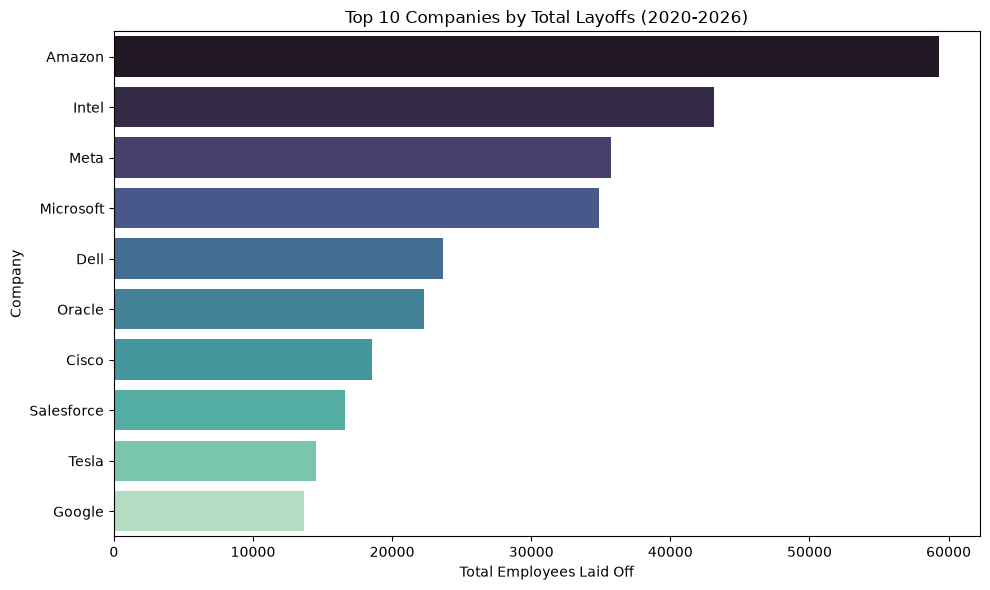

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='mako')
plt.xlabel('Total Employees Laid Off')
plt.ylabel('Company')
plt.title('Top 10 Companies by Total Layoffs (2020-2026)')
plt.tight_layout()
plt.savefig('../visuals/top_companies.png', dpi=150)
plt.show()

In [ ]:
#4: Layoffs by Country
country_layoffs = df.groupby('country')['total_laid_off'].sum().sort_values(ascending=False).head(10)
country_layoffs

country
United States     656816.0
India              67489.0
Germany            32055.0
United Kingdom     24594.0
Netherlands        22175.0
Sweden             20379.0
Canada             16536.0
Israel             16189.0
Brazil             11939.0
China               8190.0
Name: total_laid_off, dtype: float64

In [27]:
import numpy as np
import plotly.express as px

# country = df.groupby('country')['total_laid_off'].sum().reset_index()

country['log_layoffs'] = country['total_laid_off'].apply(lambda x: 0 if x == 0 else np.log10(x))
fig= px.choropleth(country,
                   locations='country',
                   locationmode='country names',
                   color='log_layoffs',
                   color_continuous_scale='Reds',
                   hover_name='country',
                   hover_data={'total_laid_off': True, 'log_layoffs': False},
                   title='Global Layoffs by Country (2020-2026)')
fig.write_html('../visuals/layoffs_world_map.html')
fig.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11824\840402168.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig= px.choropleth(country,


In [33]:
# plt.figure(figsize=(10, 6))
# sns.barplot(x=country_layoffs.values, y=country_layoffs.index, hue=country_layoffs.index, palette='rocket', legend=False)
# plt.xscale('log')
# plt.xlabel('Total Employees Laid Off (log scale)')
# plt.ylabel('country')
# plt.title('Top 10 Countries by Total Layoffs (2020-2026)')
# plt.tight_layout()
# plt.savefig('../visuals/top_countries.png', dpi=150)
# plt.show()

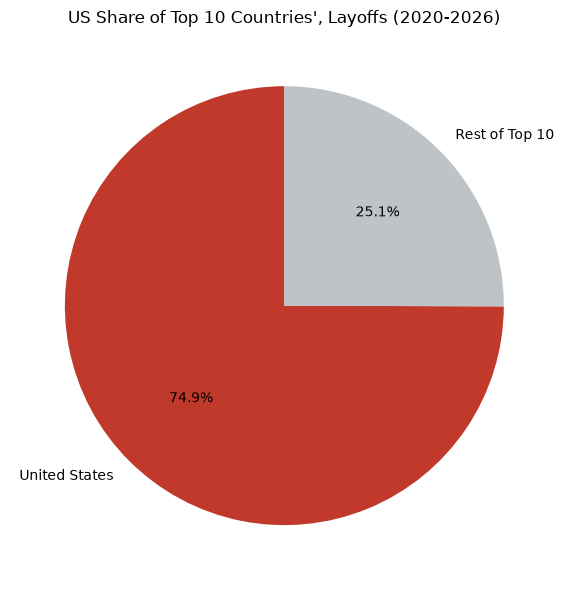

In [ ]:
#US share of global layoffs
us_total = country_layoffs['United States']
rest_total = country_layoffs.drop('United States').sum()

plt.figure(figsize=(6, 6))
plt.pie([us_total, rest_total], labels=['United States', 'Rest of Top 10'], autopct='%1.1f%%',
        colors=['#c0392b', '#bdc3c7'], startangle=90)
plt.title('US Share of Top 10 Countries\', Layoffs (2020-2026)')
plt.tight_layout()
plt.savefig('../visuals/us_vs_world_pie.png', dpi=150)
plt.show()

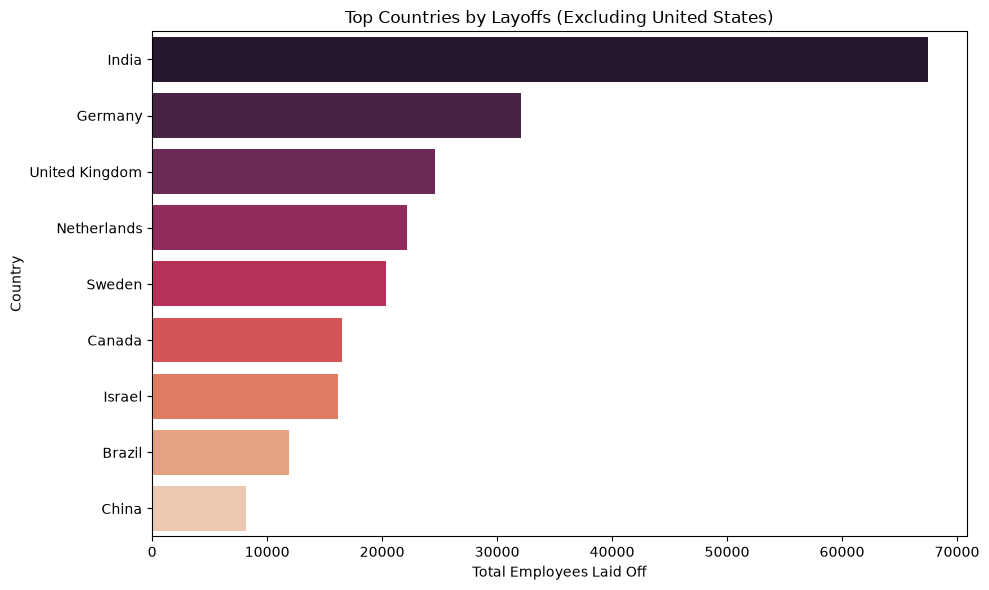

In [32]:
#Remaining countries, properly scaled
rest_countries = country_layoffs.drop('United States')

plt.figure(figsize=(10, 6))
sns.barplot(x=rest_countries.values, y=rest_countries.index, hue=rest_countries.index, palette='rocket', legend=False)
plt.xlabel('Total Employees Laid Off')
plt.ylabel('Country')
plt.title('Top Countries by Layoffs (Excluding United States)')
plt.tight_layout()
plt.savefig('../visuals/top_countries_ex_us.png', dpi=150)
plt.show()


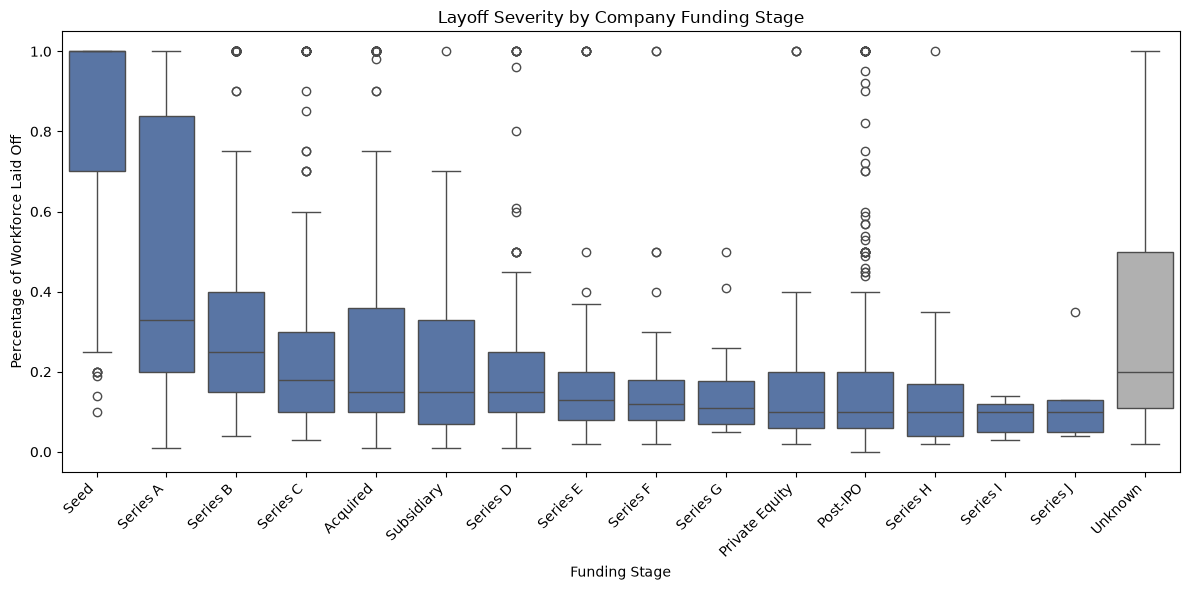

In [ ]:
#5: Layoff severity by funding stage
stage_order= df[df['stage'] != 'Unknown'].groupby('stage')['percentage_laid_off'].median().sort_values(ascending=False).index.tolist()
stage_order.append('Unknown')
palette_dict = {stage: ('#B0B0B0' if stage == 'Unknown' else '#4C72B0') for stage in stage_order}


plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='stage', y='percentage_laid_off', order=stage_order, palette=palette_dict, hue='stage', legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Funding Stage')
plt.ylabel('Percentage of Workforce Laid Off')
plt.title('Layoff Severity by Company Funding Stage')
plt.tight_layout()
plt.savefig('../visuals/stage_severity_boxplot.png', dpi=150)
plt.show()

Note: "Unknown" (17% of rows) represents companies where funding stage wasn't reported, not a distinct company category. It's included for completeness but shouldn't be compared directly to actual funding stages like Seed or Series A.

In [36]:
df[df['stage'] == 'Unknown'].shape[0]

759

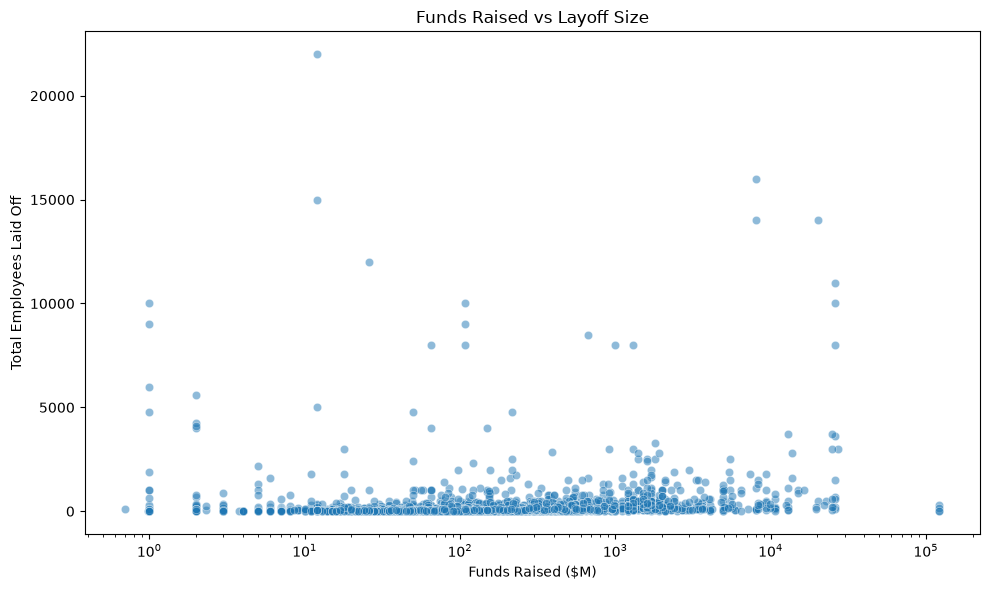

In [ ]:
#6: Correlation between funds raised and layoff size
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='funds_raised', y='total_laid_off', alpha=0.5)
plt.xscale('log')
plt.xlabel('Funds Raised ($M)')
plt.ylabel('Total Employees Laid Off')
plt.title('Funds Raised vs Layoff Size')
plt.tight_layout()
plt.savefig('../visuals/funds_vs_layoffs_scatter.png', dpi=150)
plt.show()

In [43]:
df[['funds_raised', 'total_laid_off']].corr()

,funds_raised,total_laid_off
funds_raised,1.000000,0.119333
total_laid_off,0.119333,1.000000


Finding: Funds raised has little correlation with layoff size (r = 0.12)

Companies that raised more capital were not meaningfully more or less likely to have large layoffs. This suggests layoff decisions are driven more by factors like company stage, market conditions, or leadership decisions than by how much funding a company has raised.

## Key Findings

- **Retail, Hardware, and Consumer** were the hardest-hit real industries (excluding the "Other" catch-all category)
- Layoffs spiked sharply in **early 2020 (COVID-19)** and again in **early 2023 (major tech layoffs wave)**, with a recurring smaller spike each January
- **Amazon, Intel, and Meta** had the largest cumulative layoffs among individual companies
- The **United States accounts for the vast majority of layoffs** in this dataset — over 9x India, the second-highest country
- **Earlier-stage companies (Seed, Series A) had far more severe layoffs** (often 50-100% of workforce) compared to later-stage/public companies (typically 10-20%) — suggesting early layoffs often signal company failure, while later-stage layoffs are more routine cost-cutting
- **Funds raised showed almost no correlation (r = 0.12)** with layoff size — how much a company raised doesn't meaningfully predict how big its layoffs will be

## Limitations
- ~35% of rows are missing `total_laid_off` or `percentage_laid_off` — left as null rather than estimated, since no reliable way exists to infer them
- 17% of companies have "Unknown" funding stage — included but flagged separately in stage-based analysis
- Dataset is skewed toward US/tech companies, limiting how well findings generalize globally